Import Python modules

In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import lzma
from collections import defaultdict

import os
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

Parse alignment curation logs to extract sequence counts

In [2]:
# Iterate over log files and extract summary statistics
nseqs = defaultdict(list)
segment_dirs = [d for d in os.listdir('../logs/') if os.path.isdir(os.path.join('../logs/', d))]
for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        log_file = f'../logs/{segment}/{subtype}/curate_and_extract_coding_seqs.log'

        # Read log file
        with open(log_file, 'r') as f:
            log_content = f.read()

        # Parse results from log file using regex
        total_match = re.search(r'Total sequences processed: ([\d,]+)', log_content)
        passed_match = re.search(r'Passed quality filters: ([\d,]+)', log_content)
        failed_match = re.search(r'Failed quality filters: ([\d,]+)', log_content)

        nseqs['segment_subtype'].append(f'{segment} ({subtype})')
        nseqs['total'].append(int(total_match.group(1).replace(',', '')))
        nseqs['passed'].append(int(passed_match.group(1).replace(',', '')))
        nseqs['failed'].append(int(failed_match.group(1).replace(',', '')))

nseqs_df = pd.DataFrame(nseqs)
nseqs_df['frac_passed'] = nseqs_df['passed'] / nseqs_df['total']
nseqs_df.sort_values('segment_subtype', inplace=True)
nseqs_df

,segment_subtype,total,passed,failed,frac_passed
12,HA (H1),212924,90912,122012,0.426969
11,HA (H3),230848,86912,143936,0.376490
15,HA (H5),47312,21272,26040,0.449611
14,HA (H7),6545,3229,3316,0.493354
13,HA (H9),17068,8920,8148,0.522615
10,MP (all),399109,92530,306579,0.231841
9,NA (N1),217081,82357,134724,0.379384
5,NA (N2),214226,79328,134898,0.370301
8,NA (N6),7482,4022,3460,0.537557
6,NA (N8),8962,4440,4522,0.495425


Visualize sequence filtering results across segments and subtypes

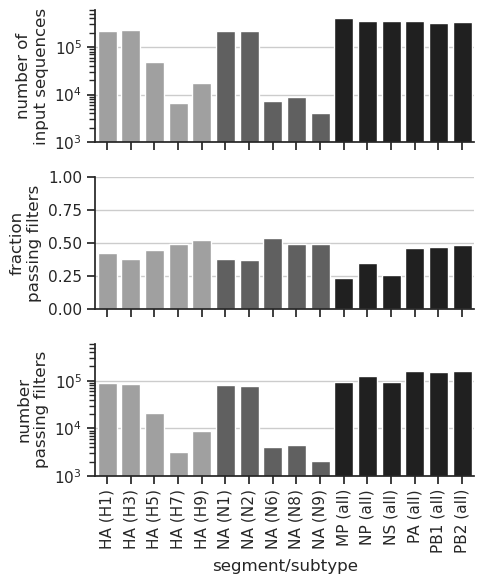

In [3]:
# Create three subplots: total number (top), fraction passed (middle), number passed on log scale (bottom)
fig, axes = plt.subplots(3, 1, figsize=(5, 6), sharex=True)

# Define custom order: HA segments first, then NA segments, then the rest alphabetically
ha_segments = sorted([s for s in nseqs_df['segment_subtype'] if s.startswith('HA (')])
na_segments = sorted([s for s in nseqs_df['segment_subtype'] if s.startswith('NA (')])
other_segments = sorted([s for s in nseqs_df['segment_subtype'] if not s.startswith('HA (') and not s.startswith('NA (')])
segment_order = ha_segments + na_segments + other_segments
nseqs_df_ordered = nseqs_df.set_index('segment_subtype').loc[segment_order].reset_index()

# Create color palette based on segment type
colors = []
for segment in nseqs_df_ordered['segment_subtype']:
    if segment.startswith('HA ('):
        colors.append('#a0a0a0')  # Medium-light gray for HA
    elif segment.startswith('NA ('):
        colors.append('#606060')  # Medium-dark gray for NA
    else:
        colors.append('#202020')  # Very dark gray for other segments

# Top subplot: total number
sns.barplot(x=nseqs_df_ordered.index, y='total', hue=nseqs_df_ordered.index, data=nseqs_df_ordered, ax=axes[0], palette=colors, legend=False)
axes[0].set_ylabel('number of\ninput sequences')
axes[0].set_yscale('log')
axes[0].set_ylim([1e3, 6e5])
axes[0].set_xlabel('')

# Middle subplot: fraction passed
sns.barplot(x=nseqs_df_ordered.index, y='frac_passed', hue=nseqs_df_ordered.index, data=nseqs_df_ordered, ax=axes[1], palette=colors, legend=False)
axes[1].set_ylabel('fraction\npassing filters')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('')

# Bottom subplot: number passed (log scale)
sns.barplot(x=nseqs_df_ordered.index, y='passed', hue=nseqs_df_ordered.index, data=nseqs_df_ordered, ax=axes[2], palette=colors, legend=False)
axes[2].set_yscale('log')
axes[2].set_ylim([1e3, 6e5])
axes[2].set_ylabel('number\npassing filters')
axes[2].set_xlabel('segment/subtype')

# Set x-tick labels
axes[2].set_xticks(range(len(nseqs_df_ordered)))
axes[2].set_xticklabels(nseqs_df_ordered['segment_subtype'], rotation=90)

# Despine all subplots and add horizontal grid lines
for ax in axes:
    sns.despine(ax=ax)
    ax.yaxis.grid(True)

plt.tight_layout()

Plot tree sizes (number of sequences per segment/subtype)

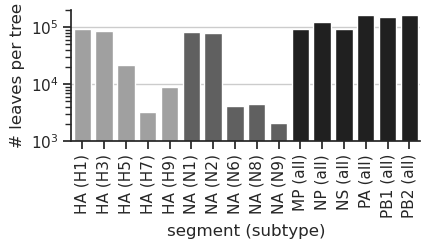

In [9]:
plt.figure(figsize=(4.5,1.7))

# Create color palette based on segment type
colors = []
for segment in nseqs_df_ordered['segment_subtype']:
    if segment.startswith('HA ('):
        colors.append('#a0a0a0')  # Medium-light gray for HA
    elif segment.startswith('NA ('):
        colors.append('#606060')  # Medium-dark gray for NA
    else:
        colors.append('#202020')  # Very dark gray for other segments

sns.barplot(x='segment_subtype', y='passed', hue='segment_subtype', data=nseqs_df_ordered, palette=colors, legend=False)
plt.xticks(rotation=90)
plt.yscale('log')
plt.ylim([1e3, 2e5])
plt.ylabel('# leaves per tree')
plt.xlabel('segment (subtype)')
plt.grid(axis='y')
sns.despine()
plt.show()

Calculate host group composition for each alignment

In [5]:
# Read metadata with host groups
meta_df = pd.read_csv('../results/combined_metadata_with_host_groups.csv')

# Remove "A / " prefix from subtype if present
if meta_df['subtype'].iloc[0].startswith('A / '):
    meta_df['subtype'] = meta_df['subtype'].apply(lambda x: x[4:])

print(f"Loaded metadata for {len(meta_df)} sequences")

# For each segment-subtype, get host group composition
host_composition = []

for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        
        print(f"Processing {segment} ({subtype})")
        
        # Read alignment to get sequence IDs
        alignment_file = f'../results/{segment}/{subtype}/curated_msa.fasta.xz'
        with lzma.open(alignment_file, 'rt') as f:
            sequences = list(SeqIO.parse(f, 'fasta'))
        
        # Get sequence IDs (skip first which is reference)
        seq_ids = [seq.id for seq in sequences[1:]]
        
        # Match to metadata and count host groups
        seq_meta = meta_df[meta_df['isolate_id'].isin(seq_ids)]
        host_counts = seq_meta['host_group'].value_counts()
        
        # Calculate fractions
        total = len(seq_ids)
        for host_group in ['human', 'avian', 'swine', 'bovine', 'other']:
            fraction = host_counts.get(host_group, 0) / total if total > 0 else 0
            host_composition.append({
                'segment_subtype': f'{segment} ({subtype})',
                'host_group': host_group,
                'fraction': fraction,
                'count': host_counts.get(host_group, 0),
                'total': total
            })

host_comp_df = pd.DataFrame(host_composition)
print(f"\nProcessed {len(segment_dirs) * len([d for seg in segment_dirs for d in os.listdir(f'../logs/{seg}/') if os.path.isdir(os.path.join(f'../logs/{seg}/', d))])} segment-subtype combinations")
host_comp_df.head(20)

Loaded metadata for 550503 sequences
Processing PB2 (all)
Processing NP (all)
Processing PB1 (all)
Processing NS (all)
Processing PA (all)
Processing NA (N2)
Processing NA (N8)
Processing NA (N9)
Processing NA (N6)
Processing NA (N1)
Processing MP (all)
Processing HA (H3)
Processing HA (H1)
Processing HA (H9)
Processing HA (H7)
Processing HA (H5)

Processed 144 segment-subtype combinations


,segment_subtype,host_group,fraction,count,total
0,PB2 (all),human,0.716533,116754,162943
1,PB2 (all),avian,0.209104,34072,162943
2,PB2 (all),swine,0.050668,8256,162943
3,PB2 (all),bovine,0.003026,493,162943
4,PB2 (all),other,0.020670,3368,162943
5,NP (all),human,0.663479,81872,123398
6,NP (all),avian,0.243108,29999,123398
7,NP (all),swine,0.065965,8140,123398
8,NP (all),bovine,0.002901,358,123398
9,NP (all),other,0.024547,3029,123398


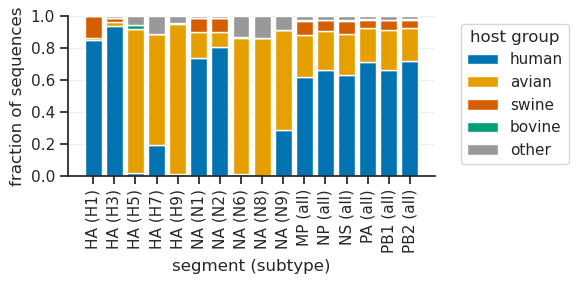

In [6]:
# Create a stacked bar plot showing host group composition for each segment-subtype
# Pivot data for stacked bar plot
pivot_df = host_comp_df.pivot(index='segment_subtype', columns='host_group', values='fraction')

# Order segments: HA first, then NA, then others alphabetically
unique_segments = pivot_df.index.unique()
ha_segments = sorted([s for s in unique_segments if s.startswith('HA (')])
na_segments = sorted([s for s in unique_segments if s.startswith('NA (')])
other_segments = sorted([s for s in unique_segments if not s.startswith('HA (') and not s.startswith('NA (')])
segment_order = ha_segments + na_segments + other_segments
pivot_df = pivot_df.loc[segment_order]

# Define host group order and colors (colorblind-friendly Okabe-Ito palette)
host_order = ['human', 'avian', 'swine', 'bovine', 'other']
host_colors = {
    'human': '#0173B2',    # Blue
    'avian': '#E69F00',    # Orange
    'swine': '#D55E00',    # Vermillion
    'bovine': '#009E73',   # Bluish green
    'other': '#999999'     # Gray
}

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(6,3))

bottom = np.zeros(len(pivot_df))
for host_group in host_order:
    if host_group in pivot_df.columns:
        values = pivot_df[host_group].values
        ax.bar(range(len(pivot_df)), values, bottom=bottom, 
               label=host_group, color=host_colors[host_group], width=0.8)
        bottom += values

# Customize plot
ax.set_xticks(range(len(pivot_df)))
ax.set_xticklabels(pivot_df.index, rotation=90)
ax.set_ylabel('fraction of sequences')
ax.set_xlabel('segment (subtype)')
ax.set_ylim([0, 1])
ax.legend(title='host group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

Calculate percent amino acid identity to reference sequence for each alignment

In [7]:
# Calculate percent amino acid identity for each sequence relative to reference
import random

identity_data = []

for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        
        print(segment, subtype)
        
        # Read alignment
        alignment_file = f'../results/{segment}/{subtype}/curated_msa.fasta.xz'
        with lzma.open(alignment_file, 'rt') as f:
            sequences = list(SeqIO.parse(f, 'fasta'))
        
        # Subset to 1000 randomly selected sequences (keep reference as first)
        if len(sequences) > 1001:
            sequences = [sequences[0]] + random.sample(sequences[1:], 1000)
        
        # First sequence is the reference
        ref_seq = str(sequences[0].seq)
        ref_length = len(ref_seq)
        
        # Calculate identity for each sequence (excluding reference itself)
        for i, seq_record in enumerate(sequences[1:], start=1):
            seq = str(seq_record.seq)
            pct_identity = sum([x == y for x, y in zip(ref_seq, seq)]) / ref_length * 100
            
            identity_data.append({
                'segment_subtype': f'{segment}_{subtype}',
                'sequence_id': seq_record.id,
                'percent_identity': pct_identity,
            })

identity_df = pd.DataFrame(identity_data)
print(f"Analyzed {len(identity_df)} sequences across {identity_df['segment_subtype'].nunique()} segment-subtype combinations")
identity_df.head(10)

PB2 all
NP all
PB1 all
NS all
PA all
NA N2
NA N8
NA N9
NA N6
NA N1
MP all
HA H3
HA H1
HA H9
HA H7
HA H5
Analyzed 16000 sequences across 16 segment-subtype combinations


,segment_subtype,sequence_id,percent_identity
0,PB2_all,EPI_ISL_346500,84.035088
1,PB2_all,EPI_ISL_20257160,91.359649
2,PB2_all,EPI_ISL_340879,91.710526
3,PB2_all,EPI_ISL_397920,84.868421
4,PB2_all,EPI_ISL_19010168,82.938596
5,PB2_all,EPI_ISL_12429515,91.622807
6,PB2_all,EPI_ISL_199168,83.070175
7,PB2_all,EPI_ISL_19754831,84.210526
8,PB2_all,EPI_ISL_16243619,84.035088
9,PB2_all,EPI_ISL_16920544,83.728070


Visualize distribution of sequence identities across segments and subtypes

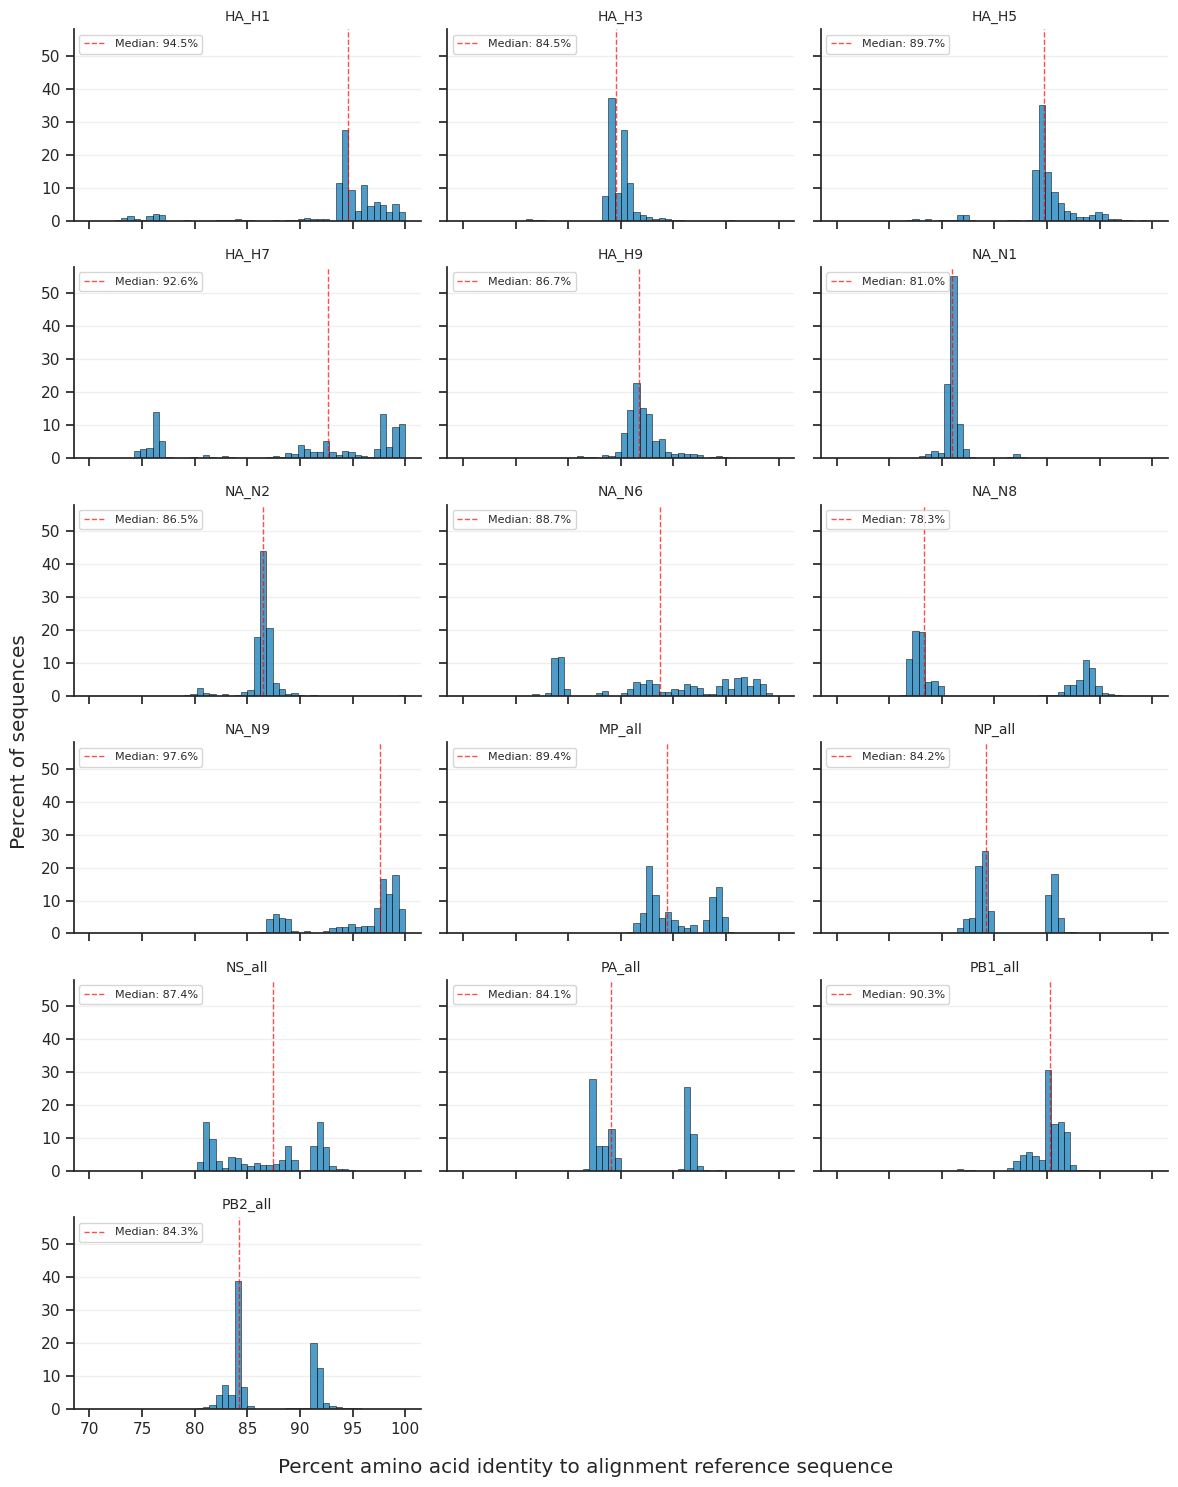

In [8]:
# Get unique segment-subtypes and order them: HA first, then NA, then others alphabetically
segment_subtypes = identity_df['segment_subtype'].unique()

ha_segments = sorted([s for s in segment_subtypes if s.startswith('HA_')])
na_segments = sorted([s for s in segment_subtypes if s.startswith('NA_')])
other_segments = sorted([s for s in segment_subtypes if not s.startswith('HA_') and not s.startswith('NA_')])
ordered_segments = ha_segments + na_segments + other_segments

# Create subplots with shared axes
n_segments = len(ordered_segments)
n_cols = 3
n_rows = (n_segments + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2.5), sharex=True, sharey=True)
axes = axes.flatten() if n_segments > 1 else [axes]

# Define common bins for all histograms
bins = np.linspace(70, 100, 51)

for idx, segment_subtype in enumerate(ordered_segments):
    ax = axes[idx]
    
    # Get data for this segment-subtype
    data = identity_df[identity_df['segment_subtype'] == segment_subtype]['percent_identity']
    
    # Plot histogram with common bins, using weights to show percentages
    weights = np.ones(len(data)) / len(data) * 100
    ax.hist(data, bins=bins, weights=weights, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(segment_subtype, fontsize=10)
    
    # Add median statistic
    median_val = data.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Median: {median_val:.1f}%')
    ax.legend(fontsize=8, loc='upper left')
    
    # Add horizontal grid lines
    ax.yaxis.grid(True, linestyle='-', alpha=0.3)
    
    sns.despine(ax=ax)

# Hide any unused subplots
for idx in range(n_segments, len(axes)):
    axes[idx].axis('off')

# Set common axis labels on outer subplots only
fig.supxlabel('Percent amino acid identity to alignment reference sequence')
fig.supylabel('Percent of sequences')

plt.tight_layout()
plt.show()